# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Loading Data

In [2]:
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "metabric_clinical_data.tsv"

print("Using:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH, sep="\t")

Using: /mnt/c/users/efazh/Projects/clinical-survival-analysis/data/raw/metabric_clinical_data.tsv
Exists: True


In [3]:
df.shape

(2509, 39)

In [4]:
df.columns.tolist()

['Study ID',
 'Patient ID',
 'Sample ID',
 'Age at Diagnosis',
 'Type of Breast Surgery',
 'Cancer Type',
 'Cancer Type Detailed',
 'Cellularity',
 'Chemotherapy',
 'Pam50 + Claudin-low subtype',
 'Cohort',
 'ER status measured by IHC',
 'ER Status',
 'Neoplasm Histologic Grade',
 'HER2 status measured by SNP6',
 'HER2 Status',
 'Tumor Other Histologic Subtype',
 'Hormone Therapy',
 'Inferred Menopausal State',
 'Integrative Cluster',
 'Primary Tumor Laterality',
 'Lymph nodes examined positive',
 'Mutation Count',
 'Nottingham prognostic index',
 'Oncotree Code',
 'Overall Survival (Months)',
 'Overall Survival Status',
 'PR Status',
 'Radio Therapy',
 'Relapse Free Status (Months)',
 'Relapse Free Status',
 'Number of Samples Per Patient',
 'Sample Type',
 'Sex',
 '3-Gene classifier subtype',
 'TMB (nonsynonymous)',
 'Tumor Size',
 'Tumor Stage',
 "Patient's Vital Status"]

In [5]:
df.head()

,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,...,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,...,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease


# Defining Survival Time & Event

In [6]:
TIME_COL = "Overall Survival (Months)"
EVENT_COL_RAW = "Overall Survival Status"

def make_event(series):
    s = series.astype(str).str.strip().str.upper()
    event = s.isin(["DECEASED", "DEAD"])
    cens  = s.isin(["LIVING", "ALIVE"])
    
    out = pd.Series(pd.NA, index=s.index)
    out[event] = 1
    out[cens] = 0
    
    return out.astype("Int64")
#######

df[TIME_COL] = pd.to_numeric(df[TIME_COL], errors="coerce")
df["event"] = make_event(df[EVENT_COL_RAW])

df = df.dropna(subset=[TIME_COL, "event"])
df = df[df[TIME_COL] > 0]
df["event"] = df["event"].astype(int)

In [7]:
df["event"].value_counts()

Series([], Name: count, dtype: int64)

In [8]:
df[TIME_COL].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Overall Survival (Months), dtype: float64

In [9]:
df[[TIME_COL, "event"]].head()

,Overall Survival (Months),event


# Kaplan-Meier Curve

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---- Load (keep if you already did it) ----
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "metabric_clinical_data.tsv"
df_raw = pd.read_csv(DATA_PATH, sep="\t")

TIME_COL = "Overall Survival (Months)"
STATUS_COL = "Overall Survival Status"

# ---- Clean time ----
df_raw[TIME_COL] = (
    df_raw[TIME_COL]
    .astype(str)
    .str.strip()
    .str.replace(",", "", regex=False)
)
df_raw[TIME_COL] = pd.to_numeric(df_raw[TIME_COL], errors="coerce")

# ---- Map status -> event (1=death, 0=censored) ----
s = df_raw[STATUS_COL].astype(str).str.strip().str.upper()

df_raw["event"] = np.where(
    s.str.startswith("1:"), 1,
    np.where(s.str.startswith("0:"), 0, np.nan)
)

# ---- Filter valid rows ----
df = df_raw.dropna(subset=[TIME_COL, "event"]).copy()
df = df[df[TIME_COL] > 0]

df[TIME_COL] = df[TIME_COL].astype(float)
df["event"] = df["event"].astype(int)

# ---- Sanity checks ----
print("Rows kept:", len(df))
print(df["event"].value_counts())
print(df[TIME_COL].describe())

Rows kept: 1980
event
1    1144
0     836
Name: count, dtype: int64
count    1980.000000
mean      125.307525
std        76.078898
min         0.100000
25%        60.891667
50%       116.500000
75%       185.141667
max       355.200000
Name: Overall Survival (Months), dtype: float64


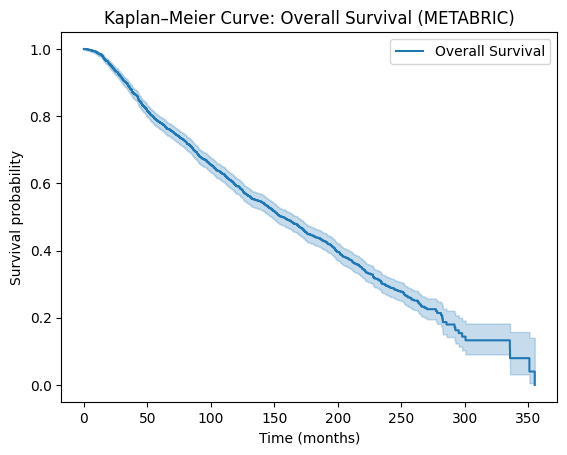

In [17]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
kmf.fit(df[TIME_COL], event_observed=df["event"], label="Overall Survival")

ax = kmf.plot()
ax.set_title("Kaplan–Meier Curve: Overall Survival (METABRIC)")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival probability")
plt.show()

## KM By Clinical Group

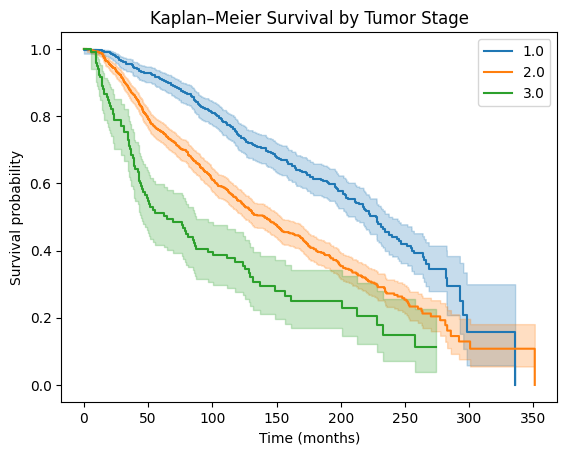

In [19]:
GROUP_COL = "Tumor Stage"

g = df.dropna(subset=[GROUP_COL]).copy()

plt.figure()
for stage, sub in g.groupby(GROUP_COL):
    if len(sub) < 50:
        continue
    kmf.fit(sub[TIME_COL], sub["event"], label=str(stage))
    kmf.plot()

plt.title("Kaplan–Meier Survival by Tumor Stage")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.show()

## Log-Rank Test

In [24]:
df["Tumor Stage"].astype(str).str.strip().value_counts().head(30)

Tumor Stage
2.0    825
nan    514
1.0    501
3.0    118
0.0     12
4.0     10
Name: count, dtype: int64

In [28]:
from lifelines.statistics import logrank_test

g = df[df["Tumor Stage"].isin([2.0, 3.0])].copy()

A = g[g["Tumor Stage"] == 2.0]
B = g[g["Tumor Stage"] == 3.0]

print("Stage II size:", len(A))
print("Stage III size:", len(B))

Stage II size: 825
Stage III size: 118


In [29]:
results = logrank_test(
    A[TIME_COL],
    B[TIME_COL],
    event_observed_A=A["event"],
    event_observed_B=B["event"],
)

print("Log-rank p-value:", results.p_value)

Log-rank p-value: 4.948638884881698e-07


### Log-rank test (Stage II vs Stage III):
The log-rank test indicates a statistically significant difference in overall survival between Stage II and Stage III breast cancer patients (p = 4.95 × 10⁻⁷), with Stage III patients exhibiting substantially poorer survival outcomes.